In [33]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy import integrate  # pip install scipy
import os
import pickle
from metrology import *

In [4]:
path_QS = os.path.dirname(os.path.dirname(os.getcwd()))+'/'
path_QS_noiseless = path_QS + 'Noiseless/'
path_QS_noiseless_data = path_QS_noiseless + 'Data/'
path_QS_noiseless_results = path_QS_noiseless_data + 'Results/'
path_QS_noiseless_states = path_QS_noiseless_data + 'Finite-energy state/'
path_QS_noise = path_QS + 'Noise/'
path_QS_noise_results = path_QS_noise + 'Results/'
path_QS_noise_results_backaction = path_QS_noise_results + 'backaction/'
path_QS_noise_results_eachnoise = path_QS_noise_results + 'eachnoise/'
path_QS_noise_results_exact = path_QS_noise_results + 'exact/'
path_QS_noise_results_states = path_QS_noise_results + 'Input_states/'
path_QS_noise_results_qorppath = path_QS_noise_results + 'q_or_p_bitstring_paths/'
path_QS_sensor = path_QS_noiseless_data + 'Finite-energy state/'
path_QS_figures = path_QS + 'Figures/'
path_QS_figures_data = path_QS_figures + 'data/'

# Displacement

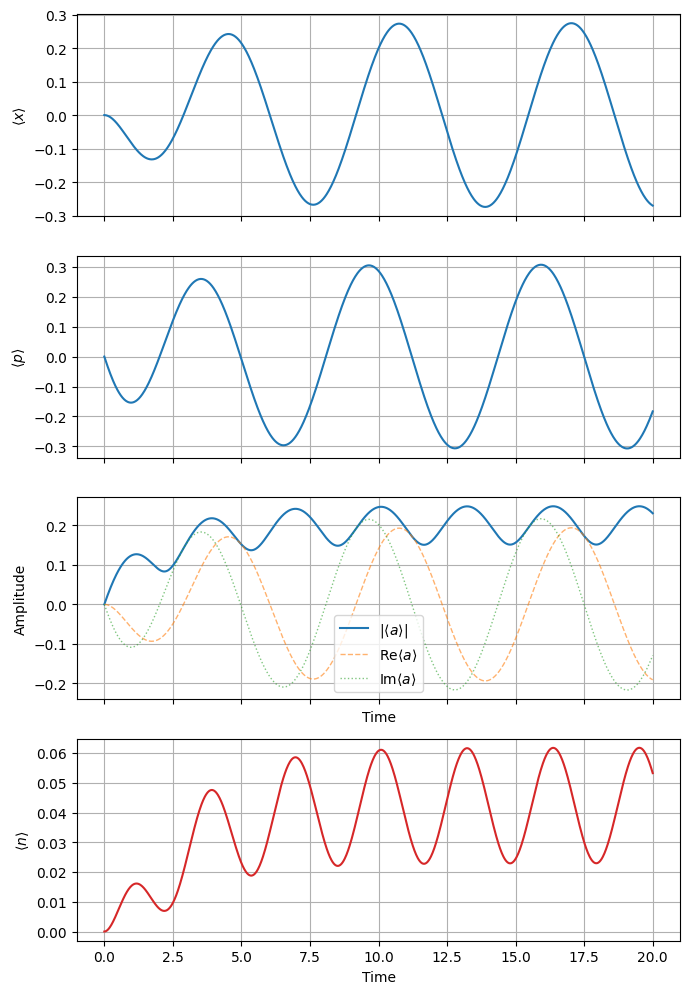

In [40]:
# QuTiP script: linearly driven harmonic oscillator, evolution from a displaced coherent state
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy import integrate  # pip install scipy


# System parameters
N = 80              # Hilbert space dimension
omega = 1.0         # oscillator frequency
omega_drive = 1.0   # drive frequency (resonant here)
epsilon = .2    # drive amplitude
alpha = 0*(1.0 + 0.5j)  # initial displacement (coherent amplitude)
T1 = 1.0          # relaxation time
Gamma = 1.0 / T1  # relaxation rate

# Operators
a = qt.destroy(N)
n_op = a.dag() * a
x_op = (a + a.dag()) / np.sqrt(2)
p_op = -1j * (a - a.dag()) / np.sqrt(2)

# Initial state: displaced vacuum = coherent state
psi0 = qt.displace(N, alpha) * qt.basis(N, 0)
# alternatively: psi0 = qt.coherent(N, alpha)

# Hamiltonian: H = hw a†a + epsilon * cos(omega_drive t) * (a + a†)
H0 = omega * n_op
H1 = (a + a.dag())

def drive(t, args):
    return epsilon * np.cos(omega_drive * t)


H = [H0, [H1, drive]]

# Time grid
tmax = 20.0
nt = 1000
tlist = np.linspace(0, tmax, nt)

# No dissipation (closed system); compute expectation values
expect_ops = [x_op, p_op, a, n_op]
result = qt.mesolve(H, psi0, tlist, c_ops=[Gamma * a], e_ops=expect_ops, args={})

x_t = np.real(result.expect[0])
p_t = np.real(result.expect[1])
a_t = result.expect[2]  # complex
n_t = np.real(result.expect[3])  # occupation number expectation
energy_t = omega * n_t  # energy expectation <H0> = omega * <n>


# Plots: x(t), p(t) and amplitude |<a>(t)|
fig, axs = plt.subplots(4, 1, figsize=(7, 10), sharex=True)
axs[0].plot(tlist, x_t, lw=1.5)
axs[0].set_ylabel(r'$\langle x\rangle$')
axs[0].grid(True)

axs[1].plot(tlist, p_t, lw=1.5)
axs[1].set_ylabel(r'$\langle p\rangle$')
axs[1].grid(True)

axs[2].plot(tlist, np.abs(a_t), lw=1.5, label=r'$|\langle a\rangle|$')
axs[2].plot(tlist, np.real(a_t), '--', lw=1, alpha=0.6, label=r'Re$\langle a\rangle$')
axs[2].plot(tlist, np.imag(a_t), ':', lw=1, alpha=0.6, label=r'Im$\langle a\rangle$')
axs[2].set_ylabel(r'Amplitude')
axs[2].set_xlabel('Time')
axs[2].legend(loc='best')
axs[2].grid(True)

axs[3].plot(tlist, energy_t, lw=1.5, color='C3')
axs[3].set_ylabel(r'$\langle n\rangle$')
axs[3].set_xlabel('Time')
axs[3].grid(True)

plt.tight_layout()
plt.show()

# Sensitivity estimation

In [17]:
# estimation of the force with Yb+

m = 2.836 * 10**-25  # mass of Yb+ ion in kg
omegax = 2 * np.pi * 1.33 * 10**6  # trap frequency in Hz
hbar = 1.0545718 * 10**-34  # reduced Planck constant in J.s
z0 = np.sqrt(hbar / (2 * m * omegax))  # zero-point motion in m
t0 = 5 * 10**(-9) #s
zeta = np.exp(1j*omegax*t0)-1
F = hbar * omegax/z0 * np.sqrt(np.pi/2)/np.abs(zeta)
print("Estimated force F =", F *10**(18), "aN")  # in atto Newton
print(np.abs(zeta))
#resonant force 
F = 30 * hbar * omegax/z0
print("Estimated resonant force F =", F *10**(18), "aN")
#lower bound
tmax = 1 * 10**-3  # s
F = np.sqrt(2*np.pi)/32/tmax * hbar /z0
print("Estimated lower bound force F =", F *10**(24), "yN")

Estimated force F = 5.60458511731109 aN
0.04178014292100008
Estimated resonant force F = 5.604988252563409 aN
Estimated lower bound force F = 1.7513054472907947 yN


In [41]:
name = 'Paper-Fig6-data'
with open(path_QS_figures_data+name+'.pkl', 'rb') as f:
    dict_fig_6 = pickle.load(f)

sensitivity_noiseless = dict_fig_6['sensitivity_noiseless']
sensitivities = dict_fig_6['sensitivities'] # 8 rounds of sBs
#116-119, delta = 0.3,  yale, 1, 2, 4, 8 rounds, p0=0, sensitivity

l = np.sqrt(2*np.pi)
vlist = np.linspace(-.25*l, .25*l, 60)
for idx in tqdm([116]):
    name = 'Data - qbits - params'+str(idx)
    results = np.load(path_QS_noise_results_qorppath+name+'.npz',allow_pickle=True)
    p_array = results['p_array']
    system_dict = results['system_dict'].item()
    r = system_dict["simulations"]["r"]
    MSE, biases, partials, variances = MSE_ML_q0_q_map(p_array, r, vlist, r, 60)
    sensitivity_1 = np.sqrt(MSE/partials**2) # 1 round sensitivity
    
name = 'data-figure-min-sensitivities-noise-deltas' # 4 rounds of sBs
dict_min_sensitivities = np.load(path_QS_figures_data+name+'.npz',allow_pickle=True)
min_sens_1 = dict_min_sensitivities['min_sens_1']

T = 25 * 10**(-6) # 25 microseconds, signal acquisition time
Tf = 1 * 10**(-3) # 1 ms, force signal duration
for i in range(4): # 8 rounds
    sensitivity = sensitivities[i]
    print('electric field frequency sensitivity (kHz):',np.sqrt(2) * np.min(sensitivity)/T * 10**(-3),i)
    print('force sensitivity (yN):',np.sqrt(2) * hbar  * np.min(sensitivity)/Tf/z0 * 10**(24),i)

sensitivity_4rounds = min_sens_1[1]
print('force sensitivity (yN) 4 rounds:',np.sqrt(2) * hbar  * np.min(sensitivity_4rounds)/Tf/z0 * 10**(24))

sensitivity_1round = np.min(sensitivity_1)
print('force sensitivity (yN) 1 round:',np.sqrt(2) * hbar  * sensitivity_1round/Tf/z0 * 10**(24))

100%|██████████| 1/1 [00:00<00:00, 163.75it/s]

electric field frequency sensitivity (kHz): 13.696591347731392 0
force sensitivity (yN): 7.655515667596643 0
electric field frequency sensitivity (kHz): 14.903648249698755 1
force sensitivity (yN): 8.330183020231235 1
electric field frequency sensitivity (kHz): 17.22680528354987 2
force sensitivity (yN): 9.628678727623448 2
electric field frequency sensitivity (kHz): 21.790046323600755 3
force sensitivity (yN): 12.179237650659127 3
force sensitivity (yN) 4 rounds: 9.063003571984554
force sensitivity (yN) 1 round: 13.72619391162605


In [ ]:
#times 
t_cool = 13.48 * 10**(-3) #13.48 ms
t_init = 0.73 * 10**(-3) #0.73 ms
t_measure = 400 * 10**(-6) #400 microseconds
Tf = 0.1 * 10**(-3) # 0.1 ms, force signal duration as in Ref.[59]
t_cooling = 13.48 * 10**(-3) #13.48 ms
total_times = t_cool + t_init + Tf + 16 * t_measure
print(t_cooling/t_measure)
force_sensitivity = np.sqrt(2) * hbar  * np.min(sensitivities[1])/Tf/z0 * 10**(24)
print('Total time per measurement (s):', total_times *10**3, 'ms')
print('Force sensitivity (yN/rtHz):', force_sensitivity)
print('Force sensitiy/sqrt(Hz):', force_sensitivity/np.sqrt(1/total_times))
total_times_4rounds = t_cool + t_init + Tf + 8 * t_measure
print('total times 4 rounds (s):', total_times_4rounds*10**3, 'ms')
print('Force sensitiy/sqrt(Hz) 4 rounds:', np.sqrt(2) * hbar  * np.min(sensitivity_4rounds)/Tf/z0 * 10**(24)/np.sqrt(1/total_times_4rounds))
total_times_1round = t_cool + t_init + Tf + 2 * t_measure
print('total times 1 round (s):', total_times_1round*10**3, 'ms')
print('Force sensitiy/sqrt(Hz) 1 round:', np.sqrt(2) * hbar  * sensitivity_1round/Tf/z0 * 10**(24)/np.sqrt(1/total_times_1round))

33.7
Total time per measurement (s): 21.61 ms
Force sensitivity (yN/rtHz): 8.330183020231235
Force sensitiy/sqrt(Hz): 1.2245652376020475
total times 4 rounds (s): 18.410000000000004 ms
Force sensitiy/sqrt(Hz) 4 rounds: 1.2296996386354948
total times 1 round (s): 16.01 ms
Force sensitiy/sqrt(Hz) 1 round: 1.7367839453386125
